# Animal Classifier
Responsi AI - Mengoptimalisasi Model untuk mengatasi **overfitting**.

In [4]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: gabrielpardede
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:49<00:00, 14.8MB/s]


In [5]:
import torch
from torch import nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)

Device Available:  cuda


In [6]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])
print(data_df["labels"].unique())
data_df.head()

['cat' 'wild' 'dog']


,image_path,labels
0,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
1,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
2,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat
3,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
4,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat


## Perubahan 1: Proporsi Split Data
- **Sebelum**: Train 70%, Val 15%, Test 15%
- **Sesudah**: Train 80%, Val 10%, Test 10%

Dengan proporsi train yang lebih besar, model memiliki lebih banyak data untuk belajar sehingga generalisasi lebih baik.

In [7]:
train = data_df.sample(frac=0.8, random_state=42)
test = data_df.drop(train.index)

val = test.sample(frac=0.5, random_state=42)
test = test.drop(val.index)

print(train.shape, test.shape, val.shape)

(12904, 2) (1613, 2) (1613, 2)


## Perubahan 2: Data Augmentation
- **Sebelum**: Hanya Resize + ToTensor (tidak ada augmentasi)
- **Sesudah**: Ditambahkan RandomHorizontalFlip, RandomRotation, ColorJitter untuk training

Augmentasi membuat model lebih robust dan mengurangi overfitting karena model melihat variasi gambar yang lebih beragam.

In [8]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [9]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform=None):
    self.dataframe = dataframe.reset_index(drop=True)
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'].values))

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image)

    return image, label

In [10]:
train_dataset = CustomImageDataset(dataframe=train, transform=train_transform)
test_dataset  = CustomImageDataset(dataframe=test,  transform=eval_transform)
val_dataset   = CustomImageDataset(dataframe=val,   transform=eval_transform)

## Perubahan 3: Hyperparameter
- **Batch Size**: 16 → 32 (lebih stabil dalam gradient estimation)
- **Epochs**: 10 → 20 (dengan early stopping, sehingga tidak perlu khawatir overfitting)
- **Learning Rate**: 1e-4 → 1e-4 (tetap, tapi ditambah scheduler)

In [11]:
LR = 1e-4
BATCH_SIZE = 32
EPOCHS = 20
PATIENCE = 5

In [12]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

## Perubahan 4: Arsitektur Model
- **Sebelum**: Tidak ada Dropout, tidak ada Batch Normalization
- **Sesudah**: Ditambahkan BatchNorm2d setelah setiap Conv layer, dan Dropout(0.5) sebelum layer output

BatchNorm menstabilkan proses training. Dropout memaksa model untuk tidak bergantung pada neuron tertentu, sehingga mengurangi overfitting.

In [13]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.bn1   = nn.BatchNorm2d(32)

    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.bn2   = nn.BatchNorm2d(64)

    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.bn3   = nn.BatchNorm2d(128)

    self.pooling = nn.MaxPool2d(2, 2)
    self.relu    = nn.ReLU()
    self.dropout = nn.Dropout(0.5)

    self.flatten = nn.Flatten()
    self.linear  = nn.Linear(128 * 16 * 16, 256)
    self.bn_fc   = nn.BatchNorm1d(256)
    self.output  = nn.Linear(256, len(data_df['labels'].unique()))

  def forward(self, x):
    x = self.relu(self.bn1(self.pooling(self.conv1(x))))
    x = self.relu(self.bn2(self.pooling(self.conv2(x))))
    x = self.relu(self.bn3(self.pooling(self.conv3(x))))

    x = self.flatten(x)
    x = self.dropout(self.relu(self.bn_fc(self.linear(x))))
    x = self.output(x)

    return x

model = Net().to(device)

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)

scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

## Perubahan 5: Training Loop dengan Early Stopping & LR Scheduler
- **Early Stopping**: Training berhenti otomatis jika val_loss tidak membaik selama `PATIENCE` epoch
- **LR Scheduler**: Learning rate dikurangi secara otomatis saat val_loss stagnan
- **Model Checkpoint**: Menyimpan model terbaik berdasarkan val_loss terendah

In [15]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
  model.train()
  total_acc_train  = 0
  total_loss_train = 0

  for inputs, labels in train_loader:
    inputs = inputs.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs    = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    total_acc_train += (torch.argmax(outputs, axis=1) == labels).sum().item()

  model.eval()
  total_loss_val = 0
  total_acc_val  = 0

  with torch.no_grad():
    for inputs, labels in val_loader:
      inputs = inputs.to(device)
      labels = labels.to(device)

      outputs  = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()
      total_acc_val  += (torch.argmax(outputs, axis=1) == labels).sum().item()

  avg_val_loss = total_loss_val / len(val_loader)
  scheduler.step(avg_val_loss)

  total_loss_train_plot.append(round(total_loss_train / len(train_loader), 4))
  total_loss_validation_plot.append(round(total_loss_val / len(val_loader), 4))
  total_acc_train_plot.append(round((total_acc_train / len(train_dataset)) * 100, 4))
  total_acc_validation_plot.append(round((total_acc_val / len(val_dataset)) * 100, 4))

  print(f'Epoch {epoch+1}/{EPOCHS} | '
        f'Train Loss: {total_loss_train_plot[-1]} | Train Acc: {total_acc_train_plot[-1]}% | '
        f'Val Loss: {total_loss_validation_plot[-1]} | Val Acc: {total_acc_validation_plot[-1]}%')

  if avg_val_loss < best_val_loss:
    best_val_loss    = avg_val_loss
    epochs_no_improve = 0
    torch.save(model.state_dict(), 'best_model.pth')
    print(f'  --> Model terbaik disimpan (val_loss={best_val_loss:.4f})')
  else:
    epochs_no_improve += 1
    if epochs_no_improve >= PATIENCE:
      print(f'Early stopping pada epoch {epoch+1}')
      break

model.load_state_dict(torch.load('best_model.pth'))
print('Model terbaik dimuat kembali untuk evaluasi.')

Epoch 1/20 | Train Loss: 0.3172 | Train Acc: 88.182% | Val Loss: 0.1158 | Val Acc: 95.9702%
  --> Model terbaik disimpan (val_loss=0.1158)
Epoch 2/20 | Train Loss: 0.1558 | Train Acc: 94.7148% | Val Loss: 0.0782 | Val Acc: 98.0161%
  --> Model terbaik disimpan (val_loss=0.0782)
Epoch 3/20 | Train Loss: 0.1178 | Train Acc: 95.978% | Val Loss: 0.0608 | Val Acc: 97.7681%
  --> Model terbaik disimpan (val_loss=0.0608)
Epoch 4/20 | Train Loss: 0.1045 | Train Acc: 96.3345% | Val Loss: 0.0493 | Val Acc: 98.3881%
  --> Model terbaik disimpan (val_loss=0.0493)
Epoch 5/20 | Train Loss: 0.0866 | Train Acc: 96.9777% | Val Loss: 0.0426 | Val Acc: 98.5741%
  --> Model terbaik disimpan (val_loss=0.0426)
Epoch 6/20 | Train Loss: 0.0818 | Train Acc: 97.0242% | Val Loss: 0.0403 | Val Acc: 98.3881%
  --> Model terbaik disimpan (val_loss=0.0403)
Epoch 7/20 | Train Loss: 0.075 | Train Acc: 97.3652% | Val Loss: 0.0467 | Val Acc: 98.3261%
Epoch 8/20 | Train Loss: 0.0676 | Train Acc: 97.5821% | Val Loss: 0.03

In [16]:
model.eval()
with torch.no_grad():
  total_loss_test = 0
  total_acc_test  = 0
  for inputs, labels in test_loader:
    inputs = inputs.to(device)
    labels = labels.to(device)

    predictions     = model(inputs)
    acc             = (torch.argmax(predictions, axis=1) == labels).sum().item()
    total_acc_test += acc
    total_loss_test += criterion(predictions, labels).item()

print(f"Test Accuracy: {round((total_acc_test/len(test_dataset))*100, 4)}%  |  "
      f"Test Loss: {round(total_loss_test/len(test_loader), 4)}")

Test Accuracy: 98.3881%  |  Test Loss: 0.0518


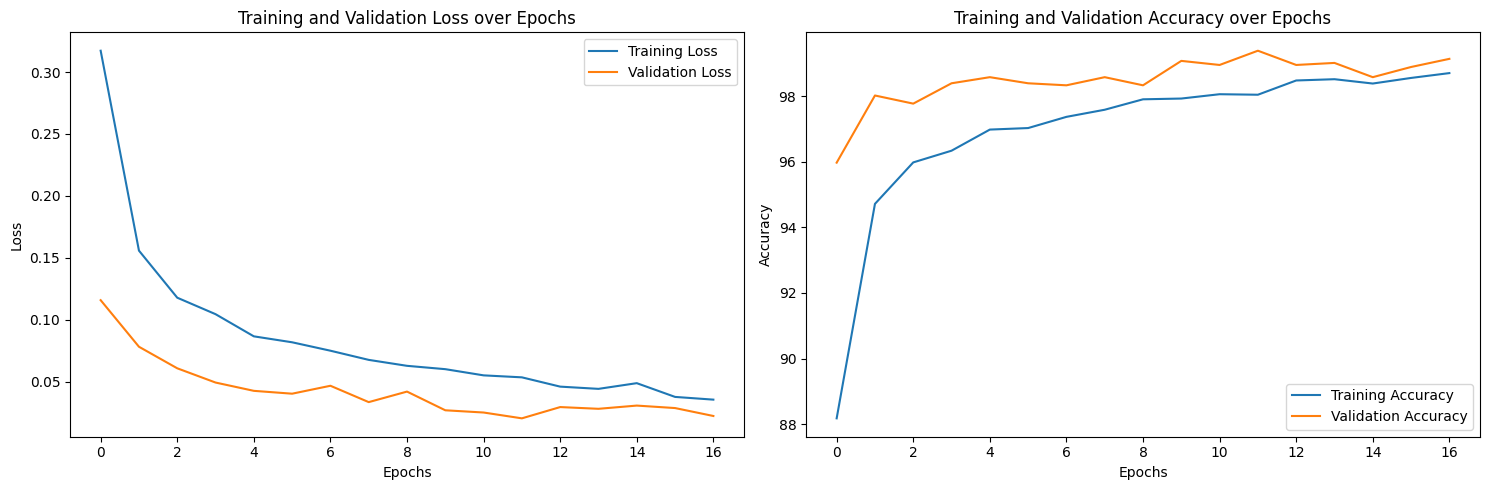

In [17]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot,      label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot,      label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()
plt.show()

In [18]:
def predict_image(image_path):
  model.eval()
  image = Image.open(image_path).convert('RGB')
  image = eval_transform(image).to(device)
  with torch.no_grad():
    output = model(image.unsqueeze(0))
  output = torch.argmax(output, axis=1).item()
  return label_encoder.inverse_transform([output])

In [19]:
predict_image("/content/cat.jpg")

array(['cat'], dtype=object)